<a href="https://colab.research.google.com/github/AishwaryaGhorpade/Data-Science/blob/main/03_EDA/Outlier_Treatment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics

# 3-Sigma Technioque (Standard Deviation)

In [5]:
df=pd.read_csv('/content/Students Annual Score in History geography subject.csv')

In [6]:
df.head()

,Gender,Test_01,Exam_01,Test_02,Exam_02,Test_03,Exam_03,Annual_Score,Success,Unnamed: 9
0,F,72.50,93.75,81.25,86.25,100.0,86.25,87.36,1,NaN
1,F,68.75,81.25,65.00,56.25,90.0,71.25,71.25,1,NaN
2,F,67.50,58.75,42.50,45.00,85.0,50.00,55.83,1,NaN
3,F,58.75,87.50,75.00,76.25,100.0,81.25,80.42,1,NaN
4,F,90.00,83.75,70.00,93.75,90.0,88.75,86.94,1,NaN


In [38]:
# def find_anomilies(data):
#   anomiles=[]
#   random_data_std=statistics.stdev(data)
#   random_data_mean=statistics.mean(data)

#   #3-standard deviation
#   anomaly_cut_off=random_data_std*3

#   lower_limit=random_data_mean-anomaly_cut_off
#   uppar_limit=random_data_mean+anomaly_cut_off

#   for outlier in data:
#     if outlier > uppar_limit or outlier < lower_limit:
#       anomiles.append(outlier)
#   return anomiles

#Z-score method
def find_anomalies_iqr(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return [x for x in data if x < lower or x > upper]

In [39]:
df.Annual_Score

,Annual_Score
0,87.36
1,71.25
2,55.83
3,80.42
4,86.94
...,...
629,65.83
630,52.50
631,54.44
632,40.00


In [44]:
res=find_anomalies_iqr(df['Annual_Score'])
res

[95.28]

In [50]:
len(res)

1

In [49]:
len(df)

634

In [45]:
data=[10, 12, 11, 13, 12, 10, 11, 200, 9, 10, 12, 8, 300]

In [46]:
list1=find_anomalies_iqr(data)

In [47]:
print(list1)

[200, 300]


In [48]:
len(list1)

2

skew for data set

In [56]:
print(df.Annual_Score.skew())

0.33120284567022756


If skew is 0.3 them data set is normally distrubuted
Types
Skew value	Meaning
≈ 0.3	symmetric (normal-like)
> 0.3	right tail (positive skew)
< 0.3	left tail (negative skew)

In [54]:
import seaborn as sns

<Axes: xlabel='Annual_Score', ylabel='Density'>

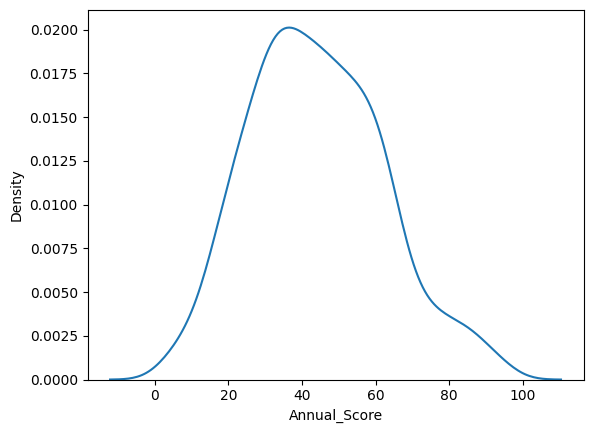

In [55]:
sns.kdeplot(df.Annual_Score)

if data is not normally distrubuted we can modithe skew using log method of numpy

In [57]:
data2 = [5, 6, 7, 5, 6, 7, 8, 6, 5, 7, 6, 50, 80, 120]

In [58]:
res1=find_anomalies_iqr(data2)

In [59]:
res1

[50, 80, 120]

In [60]:
len(res1)

3

In [61]:
len(data2)

14

(3*100)/14=21.4. which is >0.3 (positive skew)

In [63]:
df2= pd.DataFrame(data2, columns=["values"])
print(df2["values"].skew())

2.139921594982106


<Axes: ylabel='Density'>

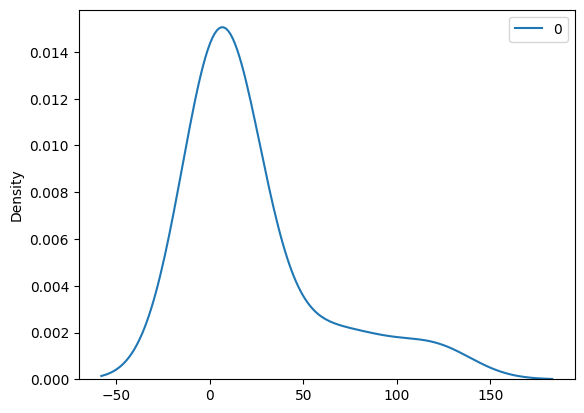

In [66]:
sns.kdeplot(df2.values) #positive skew

In [67]:
df2['values_transfrom']=np.log(df2.values)

In [71]:
list3=find_anomalies_iqr(df2.values_transfrom)
print(list3)

[3.912023005428146, 4.382026634673881, 4.787491742782046]


In [68]:
df2.values_transfrom.skew()

np.float64(1.5978261243055258)

<Axes: xlabel='values_transfrom', ylabel='Density'>

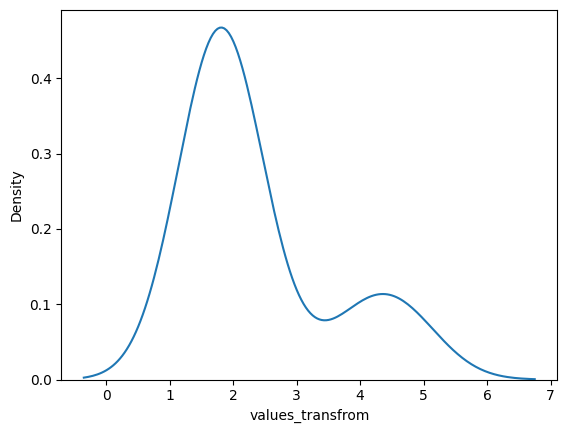

In [69]:
sns.kdeplot(df2.values_transfrom)

In [75]:
df2['values_transfrom_double']=np.log(df2.values_transfrom)

In [76]:
list4=find_anomalies_iqr(df2.values_transfrom_double)
print(list4)

[1.3640546328884455, 1.4775113193551406, 1.5660066297600124]


In [77]:
df2.values_transfrom_double.skew()

np.float64(1.4460872461453662)

<Axes: xlabel='values_transfrom_double', ylabel='Density'>

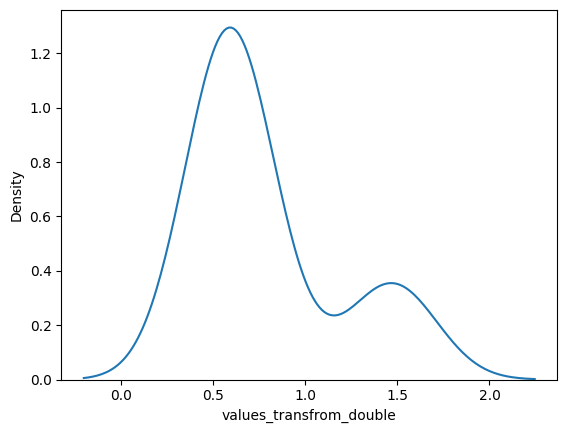

In [79]:
sns.kdeplot(df2.values_transfrom_double)

# Box Plot

<Axes: >

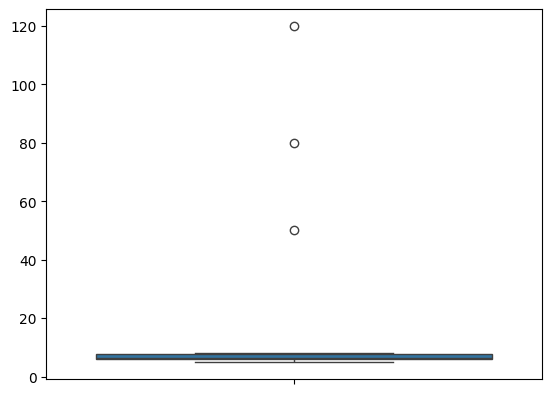

In [82]:
sns.boxplot(data=data2)

above 75 and bellow 35 can be consider as outliers